# β-limited Rates

In {doc}`branched-rates` we did an approximation to the CNO cycle that only required 3 heavy nuclei.  Now we want to revisit this and add an approximation to the hot-CNO.

## CNO vs. hot-CNO

The normal CNO cycle proceeds as:

$${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(\beta+){}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta+){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$$

and the hot-CNO cycle captures a proton onto ${}^{13}\mathrm{N}$, making ${}^{14}\mathrm{O}$:

$${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(p,\gamma){}^{14}\mathrm{O}(\beta+){}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta+){}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$$

At low temperatures, when the normal CNO cycle operates, ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ is the bottleneck, and we build up ${}^{14}\mathrm{N}$.

As the temperature rises, we transition to the hot-CNO, and now the rate-limiting
steps in the cycle are the $\beta+$-decays, ${}^{14}\mathrm{O}(,e^+\nu){}^{14}\mathrm{N}$ and ${}^{15}\mathrm{O}(,e^+\nu){}^{15}\mathrm{N}$, whose decay
times are comparable.  So we want to limit the overall flow through the entire cycle by those waiting points.

### Our approximation

Just like we did previously, we'll model our approximation off of the widely-used `aprox19` / `aprox21` networks.  These networks use 4 effective rates:

  1. ${}^{12}\mathrm{C}(p,\gamma){}^{13}\mathrm{N}(\beta^+)
     {}^{13}\mathrm{C}(p,\gamma){}^{14}\mathrm{N}$

     
     Net: ${}^{12}\mathrm{C}+2p\rightarrow{}^{14}\mathrm{N}$

  2. ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta^+)
     {}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$

     
     Net: ${}^{14}\mathrm{N}+2p\rightarrow{}^{12}\mathrm{C}+\alpha$

  3. ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}(\beta^+)
     {}^{15}\mathrm{N}(p,\gamma){}^{16}\mathrm{O}$
     
     Net: ${}^{14}\mathrm{N}+2p\rightarrow{}^{16}\mathrm{O}$

  4. ${}^{16}\mathrm{O}(p,\gamma){}^{17}\mathrm{F}(\beta^+)
     {}^{17}\mathrm{O}(p,\alpha){}^{14}\mathrm{N}$
     
     Net: ${}^{16}\mathrm{O}+2p\rightarrow{}^{14}\mathrm{N}+\alpha$

Sequences 1 and 2 represent the normal CNO cycle.  

Sequence 3 is an alternate branch, and sequence 4 represents part of the CNO-II cycle.  Without it, we
would build up ${}^{16}\mathrm{O}$, which is unphysical.

### Where to β-limit?

Now for hot-CNO, we want to $\beta$-limit the overall sequence from ${}^{12}\mathrm{C}$ back to ${}^{12}\mathrm{C}$.  The `aprox19` network chooses
to put the waiting into sequences 2 and 3, by capping the ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ rate.  In this sense, it keeps ${}^{14}\mathrm{N}$
as the bottleneck nucleus (we don't have ${}^{14}\mathrm{O}$ or ${}^{15}\mathrm{O}$ in our network, so we can't use them as the bottleneck).

We could instead choose to limit cycle 1 by ${}^{14}\mathrm{O}(\beta+){}^{14}\mathrm{N}$, which would split the bottleneck nucleus up between
${}^{12}\mathrm{C}$ and ${}^{14}\mathrm{N}$ (in an amount relative to the ${}^{14}\mathrm{O}$ and ${}^{15}\mathrm{O}$ waiting times).  But this is not the path
the original approximation took.  So we will put all the waiting into ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$.


## `BetaLimitedRate`

A {py:obj}`BetaLimitedRate <pynucastro.rates.beta_limited_rate.BetaLimitedRate>` represents a rate sequence by an effective rate capped by one or more $\beta$-decay times in the sequence.

In our case, we want to use ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ as the main rate, but cap it at the total waiting time
through ${}^{14}\mathrm{O}(\beta+){}^{14}\mathrm{N}$ and ${}^{14}\mathrm{O}(\beta+){}^{14}\mathrm{N}$

For these weak rates, ReacLib gives us the decay constant, $\lambda_{\beta^+}$, so the timescale associated with the decay is
$1 / \lambda_{\beta^+}$.  `BetaLimitedRate` accepts a list of decay rates and computes the total limiter as:

$$\frac{1}{\lambda_\mathrm{\beta^+,\mbox{eff}}} = \sum_k \frac{1}{\lambda_{\beta^+,k}}$$

In our case, this will be:

$$\frac{1}{\lambda_\mathrm{\beta^+,\mbox{eff}}} =
  \frac{1}{\lambda_{\beta^+,{}^{14}{\rm O}}} +
  \frac{1}{\lambda_{\beta^+,{}^{15}{\rm O}}}$$

We want to compare the flux of each rate.  We'll restrict ourselves to a 2-body reaction for the main rate.  For the general case, the flux of the main rate (which we'll write as $X(\xi,\gamma)Z$) is

$$F = \rho Y(\xi) Y(X) \lambda_{(\xi,\gamma)}$$

where $\lambda_{(\xi,\gamma)}$ is the $T$-dependent portion of the rate (e.g. $N_A \langle \sigma v \rangle$) we want to cap.

Our decay rate will have a flux of the form:

$$F = Y(X) \lambda_{\beta^+}$$

```{note}
In our CNO sequence, the main rate is ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ and (one of the) decay rate is ${}^{15}\mathrm{O}(\beta^+){}^{15}\mathrm{N}$.  But we don't carry ${}^{15}\mathrm{O}$, instead all of the ${}^{15}\mathrm{O}$ that we have arrives through the rate sequence, and ${}^{14}\mathrm{N}$ acts as the reservoir nucleus:

$${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}
;\xrightarrow{\beta^+};
{}^{15}\mathrm{N}
;\xrightarrow{(p,\alpha)\ \mathrm{or}\ (p,\gamma)}
\cdots$$

This is why we write the flux of the decay in terms of $Y(X)$.
```

We then want the smallest flux:

$$F = \rho Y(\xi) Y(X) \lambda_\mbox{limited} =
  \min \left (\rho Y(\xi) Y(X) \lambda_{(\xi,\gamma)},\,
              Y(\xi) \lambda_{\beta^+} \right )$$

So our `BetaLimitedRate` will return the rate as:

$$\lambda_\mbox{limited} =
  \min \left (\lambda_{(\xi,\gamma)},\,
              \frac{\lambda_{\beta^+}}{\rho Y(\xi)} \right )$$

Notice that we also need to give the nucleus, $\xi$, as part of the
approximation.  This is passed into `BetaLimitedRate` as `limiter_nucleus`.

## Exploring a limited rate

Before building the $\beta$-limited CNO cycle, let's first look at
the behavior of the limited ${}^{14}\mathrm{N}(p,\gamma){}^{15}\mathrm{O}$ rate.

In [1]:
import pynucastro as pyna

Get all the rates we need to construct the limited rate.

In [2]:
rl = pyna.ReacLibLibrary()

In [3]:
rn14pg = rl.get_rate_by_name("n14(p,g)o15")
ro15betap = rl.get_rate_by_name("o15(,)n15")
ro14betap = rl.get_rate_by_name("o14(,)n14")

Now construct the limited rate.  Notice that we pass in a list of
the $\beta$-decay rates that will act as the limiter.

In [4]:
rn14pg_betalim = pyna.rates.BetaLimitedRate(rn14pg,
                                            [ro15betap, ro14betap],
                                            limiter_nucleus="p",
                                            description="N14(p,g)O15 limited by O14(β+) and O15(β+)")

We can see from the function that this rate produces that it follows
the prescription described above:

In [5]:
print(rn14pg_betalim.function_string_py())

@numba.njit()
def N14_p_to_O15_betalimited(rate_eval, tf, rho=None, Y=None, log_scor=0.0):
    # N14 + p --> O15
    # represents the beta limiting: N14(p,g)O15 limited by O14(β+) and O15(β+)

    r0 = rate_eval.N14_p_to_O15_reaclib
    lambda_beta_tot = 0.0
    lambda_beta_tot += 1.0 / rate_eval.O15_to_N15_beta_pos_reaclib
    lambda_beta_tot += 1.0 / rate_eval.O14_to_N14_beta_pos_reaclib
    lambda_beta_tot = 1.0 / lambda_beta_tot

    limited_rate = min(r0, lambda_beta_tot / (rho * Y[jp]))
    rate_eval.N14_p_to_O15_betalimited = limited_rate




Let's plot the temperature sensitivity of these.  We'll evaluate the $\lambda$'s over a range of temperatures.  To make the comparison valid,
we'll scale the decay rates by $\rho Y(p)$.

In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [7]:
Ts = np.logspace(7, 8.5, 50)

In [8]:
rho = 100
comp = pyna.Composition(["p", "he4", "c12", "n14",
                         "n15", "o15", "o16"],
                        init="solar")

In [9]:
Yp = comp.get_molar()[pyna.Nucleus("p")]

First get the original rates

In [10]:
lam_n14pg = [rn14pg.eval(T, rho=rho, comp=comp) for T in Ts]
lam_o15betap = [ro15betap.eval(T, rho=rho, comp=comp) / (rho * Yp)
                for T in Ts]
lam_o14betap = [ro14betap.eval(T, rho=rho, comp=comp) / (rho * Yp)
                for T in Ts]

Now our limited rate

In [11]:
lam_n14pg_betalim = [rn14pg_betalim.eval(T, rho=rho, comp=comp)
                     for T in Ts]

Finally, plot it

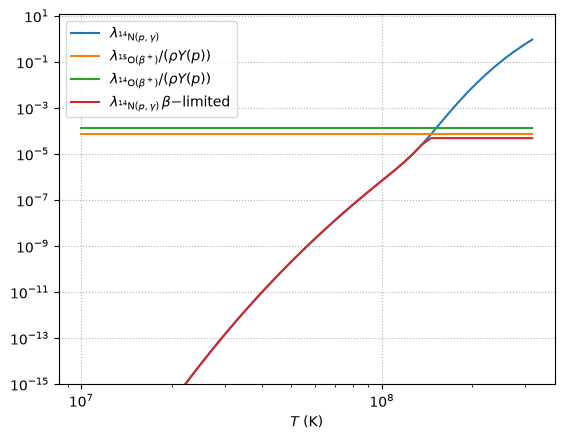

In [12]:
fig, ax = plt.subplots()
ax.loglog(Ts, lam_n14pg, label=r"$\lambda_{{}^{14}\mathrm{N}(p,\gamma)}$")
ax.loglog(Ts, lam_o15betap, label=r"$\lambda_{{}^{15}\mathrm{O}(\beta^+)} / (\rho Y(p))$")
ax.loglog(Ts, lam_o14betap, label=r"$\lambda_{{}^{14}\mathrm{O}(\beta^+)} / (\rho Y(p))$")
ax.loglog(Ts, lam_n14pg_betalim,
          label=r"$\lambda_{{}^{14}\mathrm{N}(p,\gamma)}\, \beta \rm{-limited}$")

ax.grid(ls=":")
ax.set_ylim(1.e-15,)
ax.set_xlabel(r"$T$ (K)")
ax.legend()

The red curve is our limited rate.  We see the expected behavior---it follows the $(p,\gamma)$ rate until it reaches the $\beta$-decay limit, and then it is flat afterwards.

This is why the hot-CNO cycle is essentially insensitive to temperature---you are just waiting on the $\beta$-decays.

## CNO/hot-CNO approximate network

We will follow the approach used for low-temperature CNO in  {doc}`branched-rates`, but now add the $\beta$-limiting to capture the transition to hot-CNO.

In addition to the limiting above, we will also $\beta$-limit the ${}^{16}\mathrm{O}(p,\gamma){}^{17}\mathrm{F}$ rate.

In [13]:
from pynucastro import Nucleus

Get all the rates we will need for the approximations.

In [14]:
rc12pg = rl.get_rate_by_name("c12(p,g)n13")
rn15pa = rl.get_rate_by_name("n15(p,a)c12")
rn15pg = rl.get_rate_by_name("n15(p,g)o16")
ro16pg = rl.get_rate_by_name("o16(p,g)f17")
rf17betap = rl.get_rate_by_name("f17(,)o17")

Our effective rate for ${}^{12}\mathrm{C}+2p\rightarrow{}^{14}\mathrm{N}$ is unchanged from our earlier approximation,
and uses {py:obj}`ModifiedRate <pynucastro.rates.modified_rate.ModifiedRate>`.

In [15]:
rc12_2p_n14 = pyna.ModifiedRate(rc12pg,
                                new_products=[Nucleus("n14")],
                                stoichiometry={Nucleus("p"): 2},
                                description="C12(p,g)N13(,e+nu)C13(p,g)N14")

Now the ${}^{14}\mathrm{N} + 2p$ branches.  These are {py:obj}`BranchedRate <pynucastro.rates.branched_rate.BranchedRate>`, and will use our new $\beta$-limited rate constructed above

In [16]:
rn14_2p_c12 = pyna.BranchedRate(rn14pg_betalim,
                                primary_branch=rn15pa,
                                other_branch=rn15pg,
                                stoichiometry={Nucleus("p"): 2},
                                description="N14(p,g)O15(,e+nu)N15(p,a)C12")

In [17]:
rn14_2p_o16 = pyna.BranchedRate(rn14pg_betalim,
                                primary_branch=rn15pg,
                                other_branch=rn15pa,
                                stoichiometry={Nucleus("p"): 2},
                                description="N14(p,g)O15(,e+nu)N15(p,g)O16")

Finally for ${}^{16}\mathrm{O} + 2 p \rightarrow {}^{14}\mathrm{N} + \alpha$
we first $\beta$-limit the initial rate in the sequence.

In [18]:
ro16pg_betalim = pyna.rates.BetaLimitedRate(ro16pg,
                                            [rf17betap],
                                            limiter_nucleus="p",
                                            description="O16(p,g)F17 limited by F17(β+)")

and then use this in a `ModifiedRate`:

In [19]:
ro16_2p_n14_a = pyna.ModifiedRate(ro16pg_betalim,
                                  new_products=[Nucleus("n14"),
                                                Nucleus("he4")],
                                  stoichiometry={Nucleus("p"): 2},
                                  description="O16(p,g)F15(e+nu)O17(p,a)N14")

Putting them all together, we have our approximate CNO/hot-CNO network:

In [20]:
net_reduced = pyna.PythonNetwork(rates=[rc12_2p_n14,
                                        rn14_2p_c12,
                                        rn14_2p_o16,
                                        ro16_2p_n14_a])

In [21]:
net_reduced.summary()

Network summary
---------------
  explicitly carried nuclei: 5
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 14

  rates explicitly connecting nuclei: 4
  hidden rates: 5

  reaclib rates: 8
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  beta-limited rates: 2
  approximate rates: 0
  derived rates: 0
  branched rates: 2
  modified rates: 2
  custom rates: 0


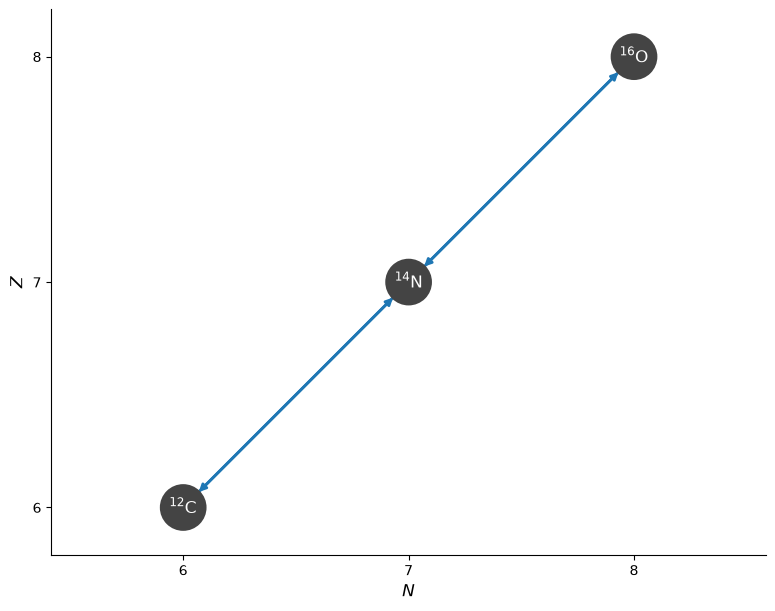

In [22]:
fig = net_reduced.plot()

## Integrating our network

Now we can build our network

In [23]:
comp_reduced = pyna.Composition(net_reduced.unique_nuclei, small=0.0)
comp_reduced[Nucleus("p")] = 0.74
comp_reduced[Nucleus("he4")] = 0.24
comp_reduced[Nucleus("c12")] = 0.003
comp_reduced[Nucleus("n14")] = 0.001
comp_reduced[Nucleus("o16")] = 0.016

We'll pick a temperature high enough that we expect hot-CNO to operate.
To avoid triggering 3-$\alpha$ (which will be present in the full network we compare with), we'll use a low density.

In [24]:
rho = 100
T = 3.e8

We'll integrate until H is depleted.

In [25]:
tmax = 1.e20

In [26]:
sol_reduced = net_reduced.integrate_network(tmax, rho, T, comp_reduced,
                                            atol=1.e-10,
                                            stopping_condition=("h1", 1.e-3))

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:495: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


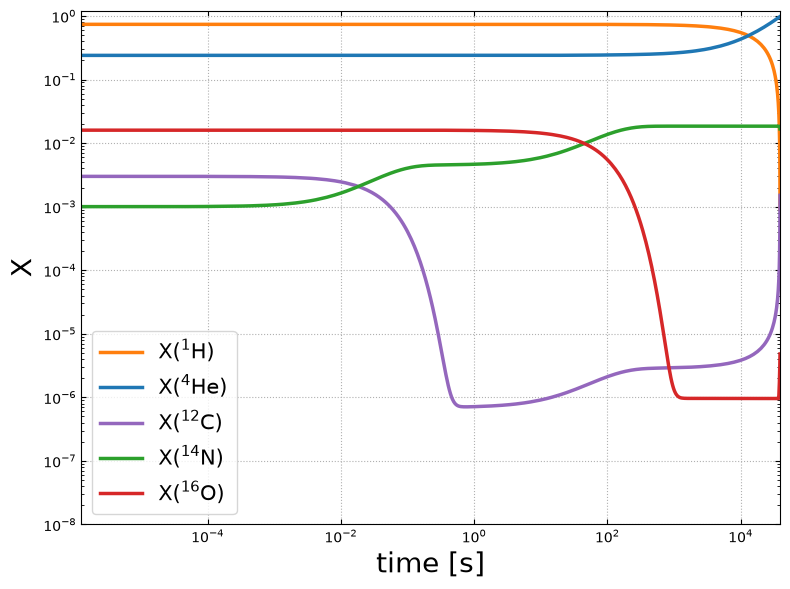

In [27]:
fig = sol_reduced.plot_evolution(ymin=1.e-8)

### Full network comparison

In [28]:
net = pyna.network_helper(["p", "he4", "c12,13",
                           "n13-15",
                           "o14-17",
                           "f17"],
                          tabular_ordering=["ffn", "oda"],
                          with_reverse=False)

In [29]:
comp = pyna.Composition(net.unique_nuclei, small=0.0)
comp[Nucleus("p")] = 0.74
comp[Nucleus("he4")] = 0.24
comp[Nucleus("c12")] = 0.003
comp[Nucleus("n14")] = 0.001
comp[Nucleus("o16")] = 0.016

In [30]:
sol = net.integrate_network(tmax, rho, T, comp,
                            atol=1.e-10,
                            stopping_condition=("h1", 1.e-3))

We'll plot the full network and our reduced network on the same axes.

In [32]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

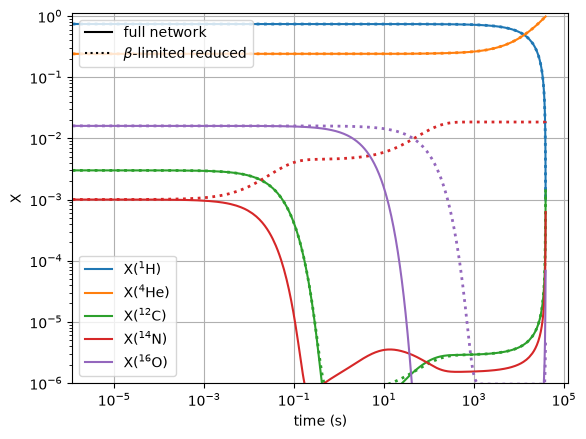

In [33]:
fig, ax = plt.subplots()

for i, nuc in enumerate(sol_reduced.unique_nuclei):
    ax.loglog(sol_reduced.t, sol_reduced.X[i, :],
              linestyle=":", lw="2", color=f"C{i}")    
    idx = sol.unique_nuclei.index(nuc)
    ax.loglog(sol.t, sol.X[idx, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}")

ax.set_ylim(1.e-6, 1.1)

ax.set_xlabel("time (s)")
ax.set_ylabel("X")
leg1 = ax.legend()
ax.add_artist(leg1)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-",  label="full network"),
    Line2D([0], [0], color="black", linestyle=":",  label=r"$\beta$-limited reduced"),
]

ax.legend(handles=style_handles, loc=2)
ax.grid()

We see excellent agreement in the $p$, ${}^{4}\mathrm{He}$, and ${}^{12}\mathrm{C}$, but the ${}^{14}\mathrm{N}$ and ${}^{16}\mathrm{O}$ do not agree.

This is not an error, but it instead reflects the choices we made in where to put the waiting-point nuclei.  In the full network, there will be a bottleneck at ${}^{14}\mathrm{O}$ and ${}^{15}\mathrm{O}$, but we don't carry those nuclei and instead choose to add those waiting points to the ${}^{14}\mathrm{N}$ sequence.  So we should compare $X({}^{14}\mathrm{N})$ in the reduceed network to $X({}^{14}\mathrm{N}) + X({}^{14}\mathrm{O}) + X({}^{15}\mathrm{O})$ oin the full network.  Likewise, we should compare ${}^{16}\mathrm{O}$ in the reduced network to
$X({}^{16}\mathrm{O}) + X({}^{17}\mathrm{F})$ in the full network.

Let's plot that comparison now.

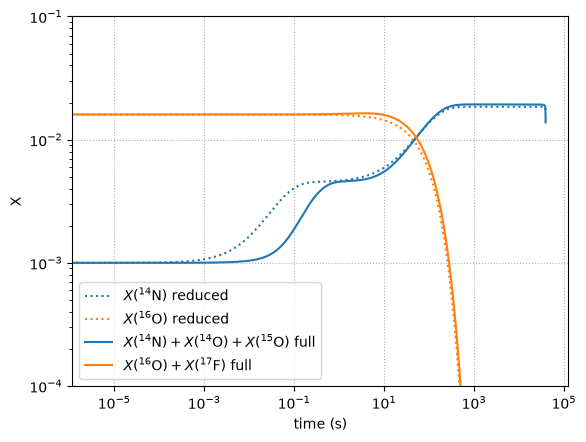

In [34]:
fig, ax = plt.subplots()

in14_reduced = sol_reduced.unique_nuclei.index(Nucleus("n14"))
io16_reduced = sol_reduced.unique_nuclei.index(Nucleus("o16"))

ax.loglog(sol_reduced.t, sol_reduced.X[in14_reduced, :],
          label=r"$X({}^{14}{\rm N})$ reduced",              
          linestyle=":", color="C0")

ax.loglog(sol_reduced.t, sol_reduced.X[io16_reduced, :],
          label=r"$X({}^{16}{\rm O})$ reduced",              
          linestyle=":", color="C1")

in14 = sol.unique_nuclei.index(Nucleus("n14"))
io14 = sol.unique_nuclei.index(Nucleus("o14"))
io15 = sol.unique_nuclei.index(Nucleus("o15"))

io16 = sol.unique_nuclei.index(Nucleus("o16"))
if17 = sol.unique_nuclei.index(Nucleus("f17"))

ax.loglog(sol.t, sol.X[in14, :] + sol.X[io14, :] + sol.X[io15, :],
          label=r"$X({}^{14}{\rm N}) + X({}^{14}{\rm O}) + X({}^{15}{\rm O})$ full",              
          linestyle="-", color="C0")

ax.loglog(sol.t, sol.X[io16, :] + sol.X[if17, :],
          label=r"$X({}^{16}{\rm O}) + X({}^{17}{\rm F})$ full",              
          linestyle="-", color="C1")

ax.set_ylim(1.e-4, 0.1)

ax.set_xlabel("time (s)")
ax.set_ylabel("X")
leg1 = ax.legend()

ax.grid(ls=":")

Now we see really good agreement.

### Non-$\beta$-limited approximation comparison

As a final comparison, let's compare to a network that does not
$\beta$-limit the approximate rates (this is what we used in 
{doc}`branched-rates`.

We'll redo the `BranchedRate` without the `BetaLimitedRate` as the underlying rate.

In [35]:
rn14_2p_c12_nolim = pyna.BranchedRate(rn14pg,
                                      primary_branch=rn15pa,
                                      other_branch=rn15pg,
                                      stoichiometry={Nucleus("p"): 2},
                                      description="N14(p,g)O15(,e+nu)N15(p,a)C12")

rn14_2p_o16_nolim = pyna.BranchedRate(rn14pg,
                                      primary_branch=rn15pg,
                                      other_branch=rn15pa,
                                      stoichiometry={Nucleus("p"): 2},
                                      description="N14(p,g)O15(,e+nu)N15(p,g)O16")

and the same with the ${}^{16}\mathrm{O}$ sequence:

In [36]:
ro16_2p_n14_a_nolim = pyna.ModifiedRate(ro16pg,
                                        new_products=[Nucleus("n14"),
                                                      Nucleus("he4")],
                                        stoichiometry={Nucleus("p"): 2})

In [37]:
net_nolim = pyna.PythonNetwork(rates=[rc12_2p_n14,
                                      rn14_2p_c12_nolim,
                                      rn14_2p_o16_nolim,
                                      ro16_2p_n14_a_nolim])

The composition is the same as the reduced network, so we can just reuse
that for our integration.

In [38]:
sol_nolim = net_nolim.integrate_network(tmax, rho, T, comp_reduced,
                                        atol=1.e-10,
                                        stopping_condition=("h1", 1.e-3))

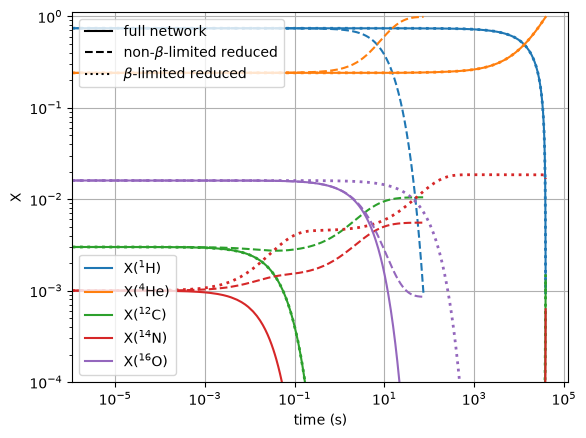

In [39]:
fig, ax = plt.subplots()

for i, nuc in enumerate(sol_reduced.unique_nuclei):
    ax.loglog(sol_reduced.t, sol_reduced.X[i, :],
              linestyle=":", lw="2", color=f"C{i}")    
    ax.loglog(sol_nolim.t, sol_nolim.X[i, :],
              linestyle="--", color=f"C{i}")    
    
    idx = sol.unique_nuclei.index(nuc)
    ax.loglog(sol.t, sol.X[idx, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}")

ax.set_ylim(1.e-4, 1.1)

ax.set_xlabel("time (s)")
ax.set_ylabel("X")
leg1 = ax.legend()
ax.add_artist(leg1)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-",  label="full network"),
    Line2D([0], [0], color="black", linestyle="--", label=r"non-$\beta$-limited reduced"),
    Line2D([0], [0], color="black", linestyle=":",  label=r"$\beta$-limited reduced"),
]

ax.legend(handles=style_handles, loc=2)

ax.grid()

Here we see that the non-$\beta$-limited reduced network burns the H
far too fast.  It gets the evolution completely wrong.